#Project Scenario: Smart Waste Classification System
A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:

Recyclable Waste

Organic Waste

Non-Recyclable Waste

You are required to build a deep learning image classifier that can perform this task.



#Task 1 – Dataset Collection (5 Marks)
Download or collect a dataset of waste images from sources

https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification?utm_source=chatgpt.com


Organize the dataset into the following folder structure:

dataset/

   train/

       recyclable/

       organic/

       non_recyclable/


   validation/

       recyclable/

       organic/

       non_recyclable/


Deliverable:
• Show the dataset structure and total number of images in each class.

In [ ]:
from google.colab import files

uploaded = files.upload()
!unzip dataset.zip

In [2]:
import os

print(os.listdir("/content/garbage classification"))

['Garbage classification']


In [3]:
import os

dataset_path = "/content/garbage classification/Garbage classification"

print("SMART WASTE CLASSIFICATION DATASET SUMMARY\n")

for category in os.listdir(dataset_path):

    category_path = os.path.join(dataset_path, category)

    if os.path.isdir(category_path):
        count = len(os.listdir(category_path))
        print(f"{category} : {count} images")

SMART WASTE CLASSIFICATION DATASET SUMMARY

plastic : 482 images
cardboard : 403 images
metal : 410 images
trash : 137 images
paper : 594 images
glass : 501 images


In [4]:
import os
import shutil
import random

# Source dataset path
source_path = "/content/garbage classification/Garbage classification"

# Target dataset path
base_path = "/content/dataset"

train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "validation")

classes = ["recyclable", "organic", "non_recyclable"]

# Create folder structure
for split in ["train", "validation"]:
    for cls in classes:
        os.makedirs(os.path.join(base_path, split, cls), exist_ok=True)

# Mapping original classes → required classes
mapping = {
    "cardboard": "recyclable",
    "glass": "recyclable",
    "metal": "recyclable",
    "paper": "recyclable",
    "plastic": "recyclable",
    "trash": "non_recyclable"
}

# Split and copy images
for original_class in os.listdir(source_path):

    class_path = os.path.join(source_path, original_class)

    if original_class not in mapping:
        continue

    new_class = mapping[original_class]

    images = os.listdir(class_path)
    random.shuffle(images)

    split_index = int(0.8 * len(images))

    train_images = images[:split_index]
    val_images = images[split_index:]

    for img in train_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_path, new_class, img)
        shutil.copy(src, dst)

    for img in val_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(val_path, new_class, img)
        shutil.copy(src, dst)

print("Dataset organized successfully!\n")

# -----------------------------------
# Print Folder Structure
# -----------------------------------

print("DATASET FOLDER STRUCTURE\n")

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

# -----------------------------------
# Print Image Count (Deliverable)
# -----------------------------------

print("\nDATASET IMAGE SUMMARY\n")

for split in ["train", "validation"]:
    print(split.upper())

    for cls in classes:
        folder = os.path.join(base_path, split, cls)
        count = len(os.listdir(folder))
        print(f"{cls} : {count} images")

    print()

Dataset organized successfully!

DATASET FOLDER STRUCTURE

dataset/
    train/
        organic/
        recyclable/
        non_recyclable/
    validation/
        organic/
        recyclable/
        non_recyclable/

DATASET IMAGE SUMMARY

TRAIN
recyclable : 1910 images
organic : 0 images
non_recyclable : 109 images

VALIDATION
recyclable : 480 images
organic : 0 images
non_recyclable : 28 images



#Task 2 – Data Preprocessing (5 Marks)
Perform the following preprocessing steps:

Resize images to a fixed size (e.g., 224×224)

Normalize pixel values

Apply data augmentation (at least 3 techniques)

Examples:

Rotation

Horizontal flip

Zoom

Brightness adjustment

Deliverable:
• Show the preprocessing pipeline code.

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset paths
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/validation"

# Image size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -----------------------------------
# Data Augmentation for Training Data
# -----------------------------------

train_datagen = ImageDataGenerator(

    rescale = 1./255,          # Normalize pixel values

    rotation_range = 30,       # Rotation augmentation
    horizontal_flip = True,    # Horizontal flip
    zoom_range = 0.2,          # Zoom augmentation
    brightness_range = [0.8,1.2],  # Brightness adjustment

)

# -----------------------------------
# Validation Data (Only Normalization)
# -----------------------------------

val_datagen = ImageDataGenerator(
    rescale = 1./255
)

# -----------------------------------
# Load Training Data
# -----------------------------------

train_generator = train_datagen.flow_from_directory(

    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical"
)

# -----------------------------------
# Load Validation Data
# -----------------------------------

val_generator = val_datagen.flow_from_directory(

    val_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical"
)

print("\nData preprocessing pipeline created successfully!")

Found 2019 images belonging to 3 classes.
Found 508 images belonging to 3 classes.

Data preprocessing pipeline created successfully!


#Task 3 – CNN Model Development (8 Marks)
Build an image classification model using CNN.

Your model should include:

Convolution layers

Pooling layers

Dense layers

Softmax output layer

Train the model and display:

Training accuracy

Validation accuracy

Training loss curve

Deliverable:

• Model architecture
• Training output
• Accuracy graph

Found 2019 files belonging to 3 classes.
Found 508 files belonging to 3 classes.
Classes: ['non_recyclable', 'organic', 'recyclable']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 225s 3s/step - accuracy: 0.9312 - loss: 0.2749 - val_accuracy: 0.9449 - val_loss: 0.1606
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.9435 - loss: 0.2015 - val_accuracy: 0.9449 - val_loss: 0.1479
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.9460 - loss: 0.1936 - val_accuracy: 0.9449 - val_loss: 0.1428


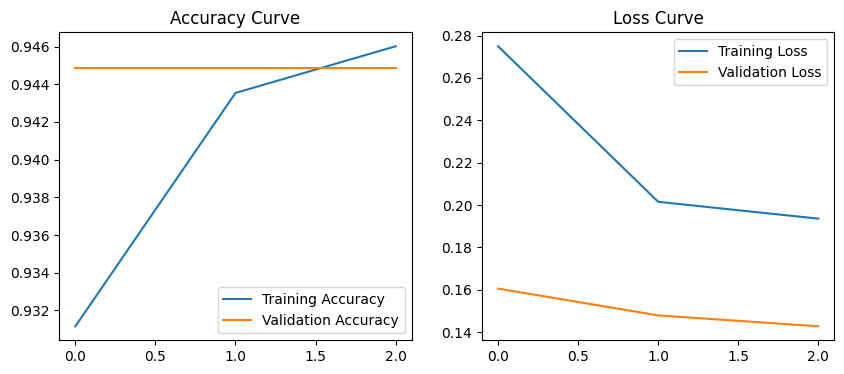

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Image parameters
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dir = "/content/dataset/train"
val_dir = "/content/dataset/validation"

# --------------------------------
# Load dataset
# --------------------------------

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize pixel values
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# --------------------------------
# CNN Model Architecture
# --------------------------------

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')   # 3 classes
])

model.summary()

# --------------------------------
# Compile Model
# --------------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --------------------------------
# Train Model
# --------------------------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

# --------------------------------
# Plot Accuracy Graph
# --------------------------------

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.legend()

# --------------------------------
# Plot Loss Graph
# --------------------------------

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.legend()

plt.show()

#Task 4 – Model Evaluation (6 Marks)
Evaluate the trained model using:

Confusion Matrix

Accuracy score

Sample predictions on test images

Deliverable:

• Confusion matrix visualization
• 5 test image predictions with predicted labels

Found 508 files belonging to 3 classes.
Classes: ['non_recyclable', 'organic', 'recyclable']
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 844ms/step

Model Accuracy: 0.9448818897637795


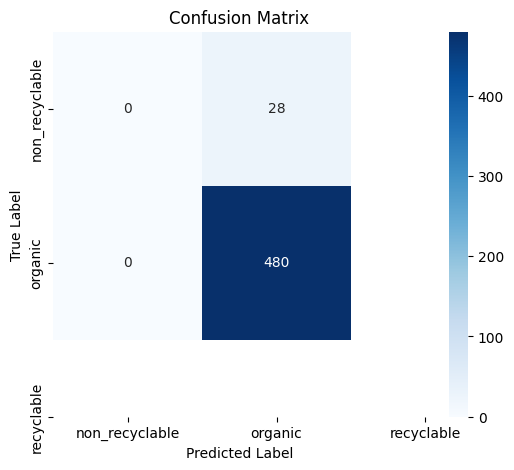

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step


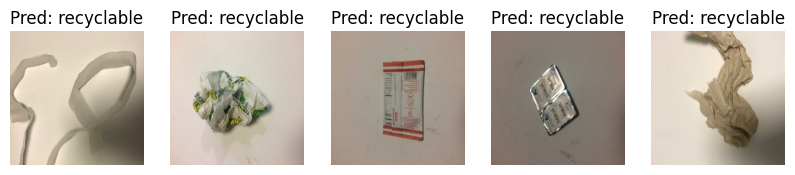

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf

# Dataset path
val_dir = "/content/dataset/validation"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# Load validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = val_ds.class_names
print("Classes:", class_names)

# Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# ----------------------------
# Get True Labels
# ----------------------------

y_true = np.concatenate([y for x, y in val_ds], axis=0)

# ----------------------------
# Get Model Predictions
# ----------------------------

predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

# ----------------------------
# Accuracy Score
# ----------------------------

accuracy = accuracy_score(y_true, y_pred)
print("\nModel Accuracy:", accuracy)

# ----------------------------
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ----------------------------
# Show 5 Sample Predictions
# ----------------------------

plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):

    predictions = model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)

    for i in range(5):

        plt.subplot(1,5,i+1)
        plt.imshow(images[i].numpy())
        plt.title("Pred: " + class_names[pred_labels[i]])
        plt.axis("off")

plt.show()

#Task 5 – Transfer Learning Implementation (6 Marks)
Improve your system by implementing Transfer Learning using a pretrained model such as:

ResNet50

MobileNetV2

VGG16

Steps:

Load a pretrained model

Freeze base layers

Add custom classification layers

Train the model

Compare results with your original CNN model.

Deliverable:

• Accuracy comparison between Custom CNN vs Transfer Learning model

Found 2019 files belonging to 3 classes.
Found 508 files belonging to 3 classes.
Classes: ['non_recyclable', 'organic', 'recyclable']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9272 - loss: 0.3028 - val_accuracy: 0.9508 - val_loss: 0.1368
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.9534 - loss: 0.1464 - val_accuracy: 0.9508 - val_loss: 0.1326
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9549 - loss: 0.1193 - val_accuracy: 0.9606 - val_loss: 0.1209


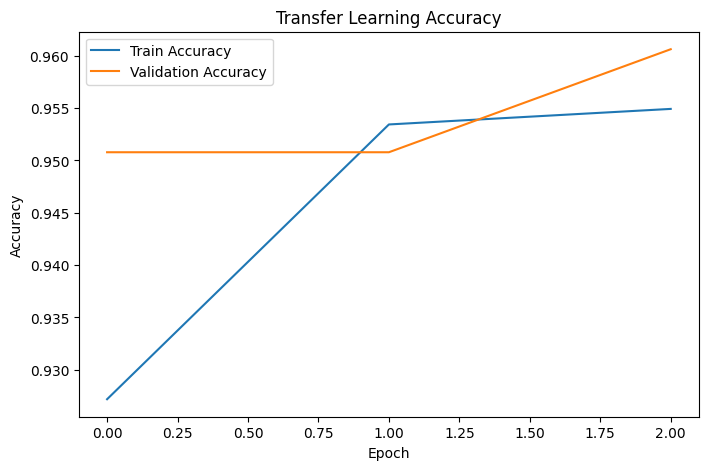

In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
import matplotlib.pyplot as plt

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dir = "/content/dataset/train"
val_dir = "/content/dataset/validation"

# --------------------------------
# Load Dataset
# --------------------------------

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# --------------------------------
# Load Pretrained Model
# --------------------------------

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# --------------------------------
# Add Custom Layers
# --------------------------------

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(3, activation="softmax")(x)

model_tl = Model(inputs=base_model.input, outputs=outputs)

model_tl.summary()

# --------------------------------
# Compile Model
# --------------------------------

model_tl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --------------------------------
# Train Model
# --------------------------------

history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

# --------------------------------
# Plot Accuracy Graph
# --------------------------------

plt.figure(figsize=(8,5))

plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Accuracy Comparison

Custom CNN Validation Accuracy: 94.49 %
Transfer Learning Validation Accuracy: 96.06 %


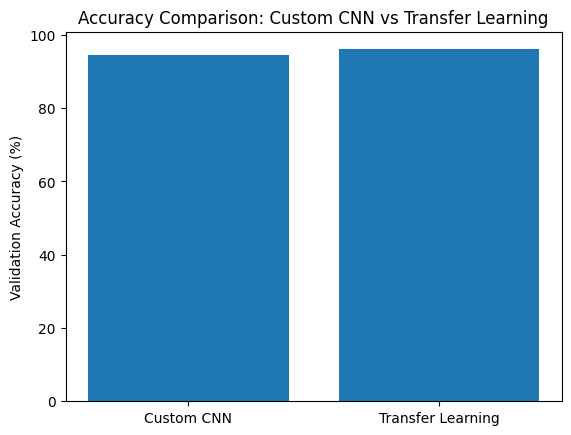

In [9]:
# Get best validation accuracy from Custom CNN
cnn_accuracy = max(history.history['val_accuracy'])

# Get best validation accuracy from Transfer Learning model
transfer_accuracy = max(history_tl.history['val_accuracy'])

print("Accuracy Comparison\n")

print("Custom CNN Validation Accuracy:", round(cnn_accuracy*100, 2), "%")
print("Transfer Learning Validation Accuracy:", round(transfer_accuracy*100, 2), "%")
import matplotlib.pyplot as plt

models = ["Custom CNN", "Transfer Learning"]
accuracies = [cnn_accuracy*100, transfer_accuracy*100]

plt.bar(models, accuracies)
plt.ylabel("Validation Accuracy (%)")
plt.title("Accuracy Comparison: Custom CNN vs Transfer Learning")

plt.show()